# Air Quality ML Project: Notebook 06
## Univariate Time-Series Forecasting: Daily PM2.5 (Track E)

**Goal:** forecast future daily PM2.5 at a single station using **only its own past
values**, no other pollutants, no weather. That is what *univariate* means.

**Why this track is different from everything before it.** In Notebooks 02–05 the rows
were interchangeable and we shuffled them freely. Here **order is the signal**.
Shuffling would let the model peek at the future to predict the past, the most common
and most damaging mistake in time-series work.

**Lab covered:** 13 (Univariate Time Series Analysis)

> Run **Notebook 01** first, this loads `beijing_aqi_clean.parquet`.


## 0. Setup

This notebook needs `statsmodels`:
```bash
uv pip install statsmodels
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_theme(style="whitegrid")
STATION = "Aotizhongxin"
print("Setup complete. Station:", STATION)

Setup complete. Station: Aotizhongxin


## 1. Build the Daily Series

We take one station's hourly readings and average them to **daily** means. Daily is the
right granularity: hourly PM2.5 is dominated by short-term noise, while daily values
show the trends and seasonality a forecast can actually capture.

In [2]:
df = pd.read_parquet("beijing_aqi_clean.parquet")

series = (df[df["station"] == STATION]
            .set_index("datetime")["PM2.5"]
            .resample("D").mean())

print("Daily observations:", len(series))
print("Date range:", series.index.min().date(), "to", series.index.max().date())
print("Missing days:", int(series.isna().sum()))
print(f"Min {series.min():.1f} | Mean {series.mean():.1f} | Max {series.max():.1f} ug/m3")

Daily observations: 1461
Date range: 2013-03-01 to 2017-02-28
Missing days: 15
Min 4.9 | Mean 82.7 | Max 512.3 ug/m3


### Filling the gaps: and why the method matters

15 days have no valid readings at all. For time-series models the index must be a
**complete, evenly-spaced** calendar, so we interpolate rather than drop: dropping days
would silently shift every subsequent date and corrupt the seasonal structure.

We use **time-based linear interpolation**, which respects the actual gap length. This
is a defensible choice for 15 days out of 1,461 (1%), and it must be noted that
report, interpolated points are estimates, not measurements.

In [3]:
series = series.interpolate(method="time")
series.index.freq = "D"          # tell statsmodels the frequency explicitly
print("Missing after interpolation:", int(series.isna().sum()))
print("Series length:", len(series))

Missing after interpolation: 0
Series length: 1461


## 2. Visual Inspection

Always look at the series before modelling it. We want to see: is there a **trend**?
Is there **seasonality**? Is the variance stable?

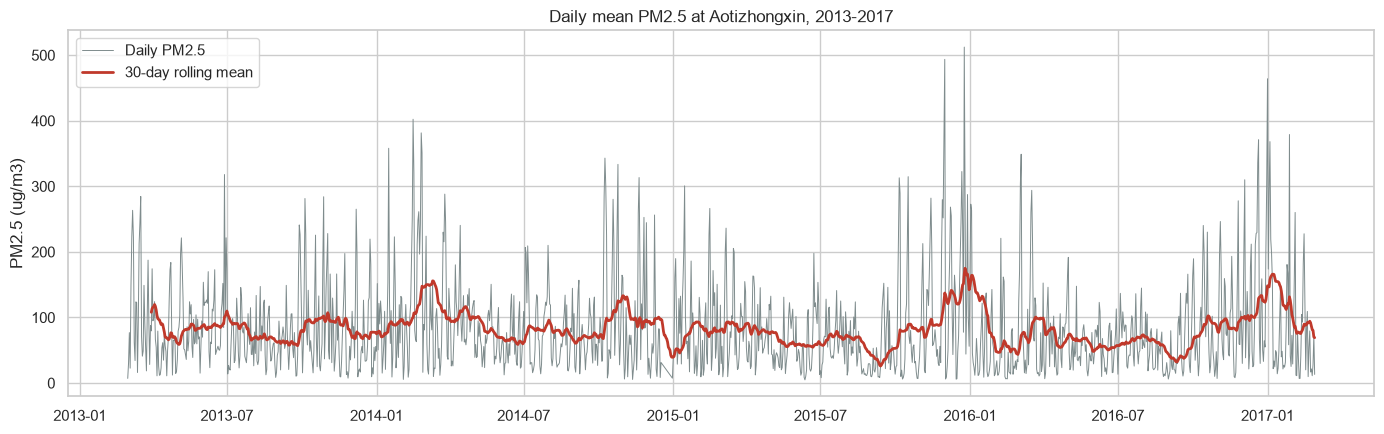

In [4]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(series.index, series.values, lw=0.7, color="#7f8c8d", label="Daily PM2.5")
ax.plot(series.index, series.rolling(30).mean(), lw=2, color="#c0392b",
        label="30-day rolling mean")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title(f"Daily mean PM2.5 at {STATION}, 2013-2017")
ax.legend()
plt.tight_layout(); plt.show()

### Seasonality by month
The rolling mean hints at a yearly rhythm. Grouping by calendar month makes it explicit.

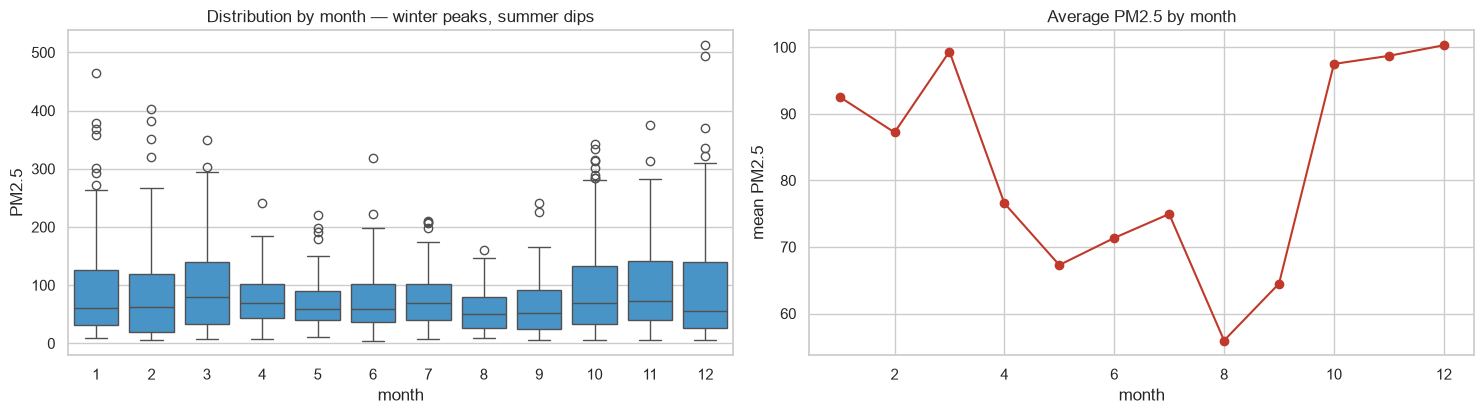

Highest month: 12 (100.3) | Lowest month: 8 (55.9)


In [5]:
tmp = series.to_frame("PM2.5")
tmp["month"] = tmp.index.month
tmp["year"]  = tmp.index.year

fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
sns.boxplot(data=tmp, x="month", y="PM2.5", ax=axes[0], color="#3498db")
axes[0].set_title("Distribution by month — winter peaks, summer dips")

monthly = tmp.groupby("month")["PM2.5"].mean()
axes[1].plot(monthly.index, monthly.values, "o-", color="#c0392b")
axes[1].set_xlabel("month"); axes[1].set_ylabel("mean PM2.5")
axes[1].set_title("Average PM2.5 by month")
plt.tight_layout(); plt.show()

print("Highest month:", int(monthly.idxmax()), f"({monthly.max():.1f})",
      "| Lowest month:", int(monthly.idxmin()), f"({monthly.min():.1f})")

## 3. Seasonal Decomposition

`seasonal_decompose` splits the series into **trend + seasonal + residual**. We use
`period=365` to look for an annual cycle (four full cycles are available in the data).

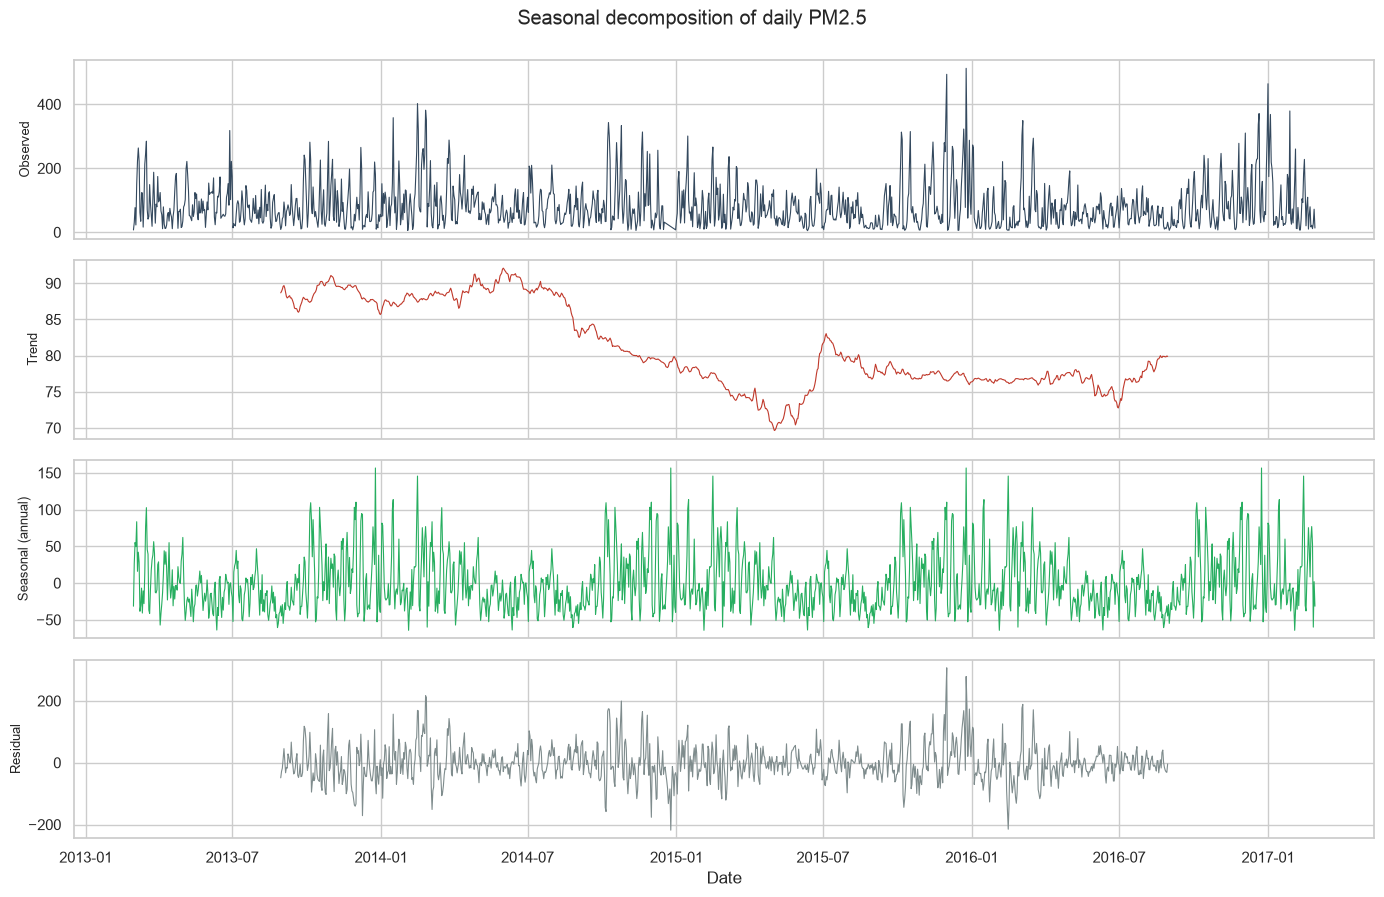

Seasonal amplitude is 55.1% of the total series variation.


In [6]:
decomp = seasonal_decompose(series, model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
for ax, comp, name, colr in zip(
        axes,
        [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
        ["Observed", "Trend", "Seasonal (annual)", "Residual"],
        ["#34495e", "#c0392b", "#27ae60", "#7f8c8d"]):
    ax.plot(comp.index, comp.values, lw=0.8, color=colr)
    ax.set_ylabel(name, fontsize=9)
axes[-1].set_xlabel("Date")
fig.suptitle("Seasonal decomposition of daily PM2.5", y=0.995)
plt.tight_layout(); plt.show()

seasonal_strength = decomp.seasonal.std() / series.std()
print(f"Seasonal amplitude is {seasonal_strength*100:.1f}% of the total series variation.")

## 4. Stationarity: the Augmented Dickey-Fuller Test

ARIMA requires a **stationary** series: constant mean and variance over time. The ADF
test's null hypothesis is "the series has a unit root" (i.e. is *non*-stationary).

- **p < 0.05** → reject the null → the series **is** stationary → no differencing (`d = 0`)
- **p ≥ 0.05** → difference the series and retest

In [7]:
def adf_report(s, label):
    stat, p, lags, nobs, crit, _ = adfuller(s.dropna())
    print(f"{label}")
    print(f"   ADF statistic : {stat:.4f}")
    print(f"   p-value       : {p:.6f}")
    print(f"   critical 5%   : {crit['5%']:.4f}")
    print(f"   -> {'STATIONARY' if p < 0.05 else 'NON-STATIONARY'}")
    return p

p_level = adf_report(series, "Original series")
print()
p_diff  = adf_report(series.diff(), "First-differenced series")

Original series
   ADF statistic : -17.4061
   p-value       : 0.000000
   critical 5%   : -2.8635
   -> STATIONARY

First-differenced series
   ADF statistic : -13.5509
   p-value       : 0.000000
   critical 5%   : -2.8636
   -> STATIONARY


> ### 📌 A useful negative result: this series needs **no differencing**
>
> The ADF test rejects the unit-root null decisively, so `d = 0`. That makes physical
> sense, PM2.5 concentration is **mean-reverting**: pollution builds up, then wind and
> rain clear it out. It cannot wander indefinitely like a stock price can.
>
> Many tutorials difference automatically. Testing first, finding `d = 0`, and saying so
> is better practice, and it means our ARIMA is really an **ARMA** model.

## 5. ACF and PACF: Choosing *p* and *q*

These two plots are the classic Box–Jenkins way to pick ARIMA orders:

- **ACF** (autocorrelation), correlation with each lag; guides the **MA order `q`**
- **PACF** (partial autocorrelation), correlation with a lag after removing the
  intervening lags; guides the **AR order `p`**

Bars outside the shaded band are statistically significant.

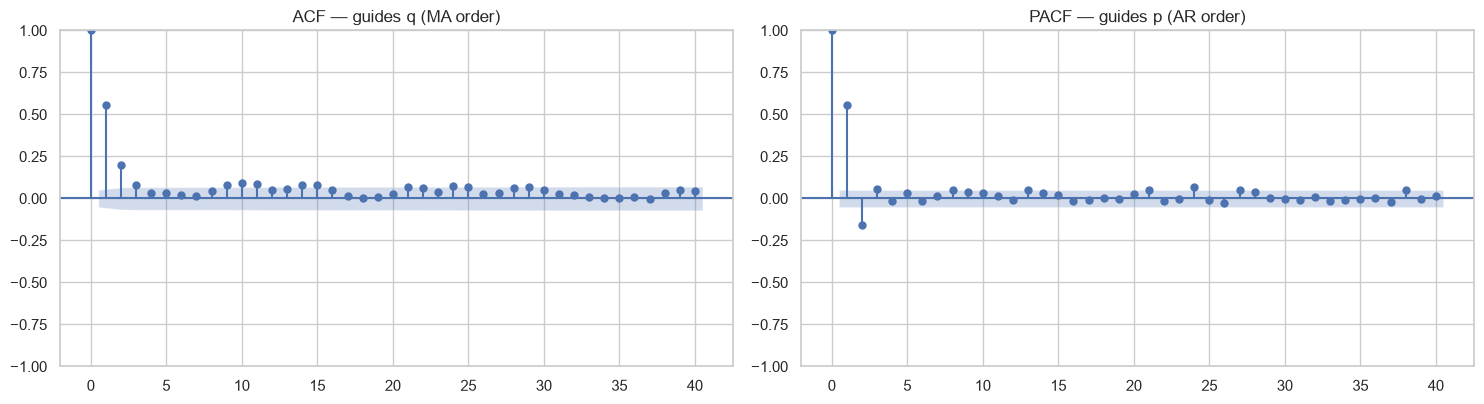

Autocorrelation at lag 1: 0.557   lag 2: 0.2   lag 7: 0.014


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
plot_acf(series, lags=40, ax=axes[0])
axes[0].set_title("ACF — guides q (MA order)")
plot_pacf(series, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF — guides p (AR order)")
plt.tight_layout(); plt.show()

ac = acf(series, nlags=10)
print("Autocorrelation at lag 1:", round(ac[1], 3), "  lag 2:", round(ac[2], 3),
      "  lag 7:", round(ac[7], 3))

## 6. ⭐ Chronological Train/Test Split

**This is the single most important cell in the notebook.**

Everywhere else in this project we used `train_test_split(.., shuffle=True)`. Doing
that here would be **fatal**: random selection puts future days in the training set and
past days in the test set, so the model learns from information that would not exist at
prediction time. Scores would look excellent and mean nothing.

For time series the split must be **a cut in time**: train on the earliest data, test on
the most recent. We hold out the final **90 days**.

Train: 1371 days  (2013-03-01 -> 2016-11-30)
Test : 90 days  (2016-12-01 -> 2017-02-28)

NOTE: no shuffling, no random_state — the split is purely chronological.


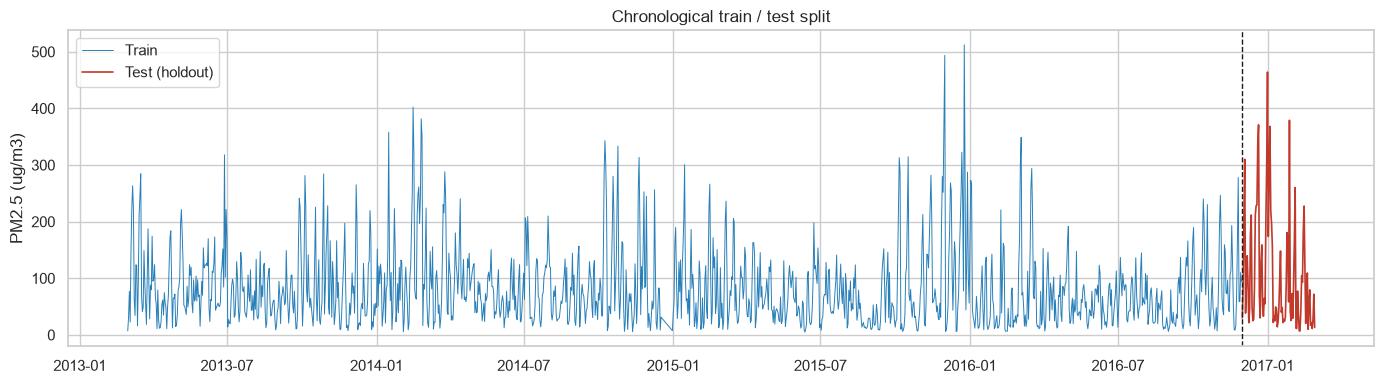

In [9]:
TEST_DAYS = 90
train, test = series[:-TEST_DAYS], series[-TEST_DAYS:]

print(f"Train: {len(train)} days  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test : {len(test)} days  ({test.index.min().date()} -> {test.index.max().date()})")
print()
print("NOTE: no shuffling, no random_state — the split is purely chronological.")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train.values, lw=0.7, color="#2980b9", label="Train")
ax.plot(test.index,  test.values,  lw=1.2, color="#c0392b", label="Test (holdout)")
ax.axvline(test.index[0], color="k", ls="--", lw=1)
ax.set_ylabel("PM2.5 (ug/m3)"); ax.set_title("Chronological train / test split")
ax.legend()
plt.tight_layout(); plt.show()

> ### ⚠️ A consequence of splitting chronologically on a seasonal series
>
> The holdout is **1 December 2016 – 28 February 2017**. i.e. entirely **winter**, the
> single most polluted and most volatile season (December averages 100 µg/m³ against
> August's 56). So the test set is not a representative sample of the year; it is the
> hardest quarter in it.
>
> This is an unavoidable side effect of doing the split *correctly*. Randomly sampling
> test days would be more "representative" but would leak the future. Two honest options:
>
> - Report as-is and state the caveat (what we do here), or
> - Use **rolling-origin cross-validation** (`TimeSeriesSplit`), which repeats the
>   evaluation across several chronological folds so different seasons are tested.
>
> It also explains the large error values that follow: winter PM2.5 swings between ~10
> and ~500 µg/m³ within days, so a daily RMSE near 90–100 reflects a genuinely volatile
> target, not a broken model.

## 7. Evaluation Metrics

Same RMSE and MAE as the regression track, plus **MAPE** (mean absolute percentage
error), which is popular in forecasting because it is unit-free.

> ⚠️ **Read MAPE with suspicion on this series.** MAPE divides by the actual value, and
> daily PM2.5 ranges from ~5 to ~500 µg/m³, two orders of magnitude. On a clean 5 µg/m³
> day, a perfectly reasonable prediction of 80 registers as a **1,500% error**. MAPE here
> is therefore dominated by the cleanest days and will look alarmingly large no matter
> how good the model is. We report it because it is a standard forecasting metric, but
> **RMSE and MAE are the trustworthy ones** for this data. Knowing when a popular metric
> is the wrong tool is itself worth a mark.

In [10]:
def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def evaluate_ts(name, y_true, y_pred, store):
    y_pred = np.asarray(y_pred, dtype=float)
    res = {"Model": name,
           "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
           "MAE":  float(mean_absolute_error(y_true, y_pred)),
           "MAPE (%)": mape(np.asarray(y_true, dtype=float), y_pred)}
    store.append(res)
    print(f"{name:28s} RMSE={res['RMSE']:6.2f}  MAE={res['MAE']:6.2f}  MAPE={res['MAPE (%)']:6.1f}%")
    return res

print("Metrics defined.")

Metrics defined.


## 8. Baselines First

Never report a forecasting model without a naive benchmark, a "sophisticated" model
that cannot beat *"tomorrow equals today"* has learned nothing.

- **Naive**. repeat the last observed value
- **Seasonal naive (7)**. repeat the value from the same weekday last week
- **Moving average (7)**. repeat the mean of the last 7 days
- **Train mean**. the constant long-run average

In [11]:
ms_results = []          # multi-step (forecast all 90 days at once)
forecasts  = {}

f_naive    = np.repeat(train.iloc[-1], TEST_DAYS)
f_snaive   = np.tile(train.iloc[-7:].values, int(np.ceil(TEST_DAYS/7)))[:TEST_DAYS]
f_ma7      = np.repeat(train.iloc[-7:].mean(), TEST_DAYS)
f_mean     = np.repeat(train.mean(), TEST_DAYS)

for nm, f in [("Naive (last value)", f_naive), ("Seasonal naive (7d)", f_snaive),
              ("Moving average (7d)", f_ma7), ("Train mean", f_mean)]:
    evaluate_ts(nm, test.values, f, ms_results)
    forecasts[nm] = f

Naive (last value)           RMSE=103.17  MAE= 78.19  MAPE= 173.9%
Seasonal naive (7d)          RMSE=120.90  MAE= 90.69  MAPE= 232.2%
Moving average (7d)          RMSE=103.00  MAE= 86.03  MAPE= 229.5%
Train mean                   RMSE=105.75  MAE= 75.89  MAPE= 146.7%


## 9. Exponential Smoothing Models

- **SES**. weighted average of the past, weights decaying exponentially. No trend, no season.
- **Holt**. SES plus a trend term.
- **Holt-Winters**. SES plus trend *and* seasonality (we use a 7-day period; a 365-day
  seasonal period is not estimable from ~4 cycles).

In [12]:
ses = SimpleExpSmoothing(train).fit()
evaluate_ts("Simple Exp Smoothing", test.values, ses.forecast(TEST_DAYS), ms_results)
forecasts["Simple Exp Smoothing"] = ses.forecast(TEST_DAYS).values

holt = ExponentialSmoothing(train, trend="add", seasonal=None).fit()
evaluate_ts("Holt (trend)", test.values, holt.forecast(TEST_DAYS), ms_results)
forecasts["Holt (trend)"] = holt.forecast(TEST_DAYS).values

hw = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7).fit()
evaluate_ts("Holt-Winters (7d season)", test.values, hw.forecast(TEST_DAYS), ms_results)
forecasts["Holt-Winters (7d season)"] = hw.forecast(TEST_DAYS).values

Simple Exp Smoothing         RMSE=102.99  MAE= 78.57  MAPE= 177.0%
Holt (trend)                 RMSE=103.09  MAE= 79.28  MAPE= 182.2%
Holt-Winters (7d season)     RMSE=103.03  MAE= 80.56  MAPE= 193.7%


## 10. ARIMA: Order Selection by AIC

ACF/PACF give a starting range; we then search a small grid and pick the lowest **AIC**
(Akaike Information Criterion), which rewards fit and penalises complexity.

`d = 0` throughout, because Section 4 showed the series is already stationary.

In [13]:
import itertools

best_aic, best_order, rows = np.inf, None, []
for p, d, q in itertools.product(range(4), [0], range(4)):
    if p == 0 and q == 0:
        continue
    try:
        m = ARIMA(train, order=(p, d, q)).fit()
        rows.append({"order": f"({p},{d},{q})", "AIC": m.aic, "BIC": m.bic})
        if m.aic < best_aic:
            best_aic, best_order = m.aic, (p, d, q)
    except Exception:
        pass

aic_df = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
print("Best order by AIC:", best_order, f"(AIC={best_aic:.1f})")
aic_df.head(8).round(1)

Best order by AIC: (2, 0, 2) (AIC=14876.2)


,order,AIC,BIC
0,"(2,0,2)",14876.2,14907.6
1,"(1,0,1)",14877.2,14898.1
2,"(0,0,3)",14877.3,14903.4
3,"(3,0,3)",14878.8,14920.5
4,"(1,0,3)",14878.9,14910.3
5,"(2,0,1)",14879.0,14905.2
6,"(1,0,2)",14879.1,14905.2
7,"(3,0,0)",14879.5,14905.7


In [14]:
arima = ARIMA(train, order=best_order).fit()
fc_arima = arima.get_forecast(TEST_DAYS)
evaluate_ts(f"ARIMA{best_order}", test.values, fc_arima.predicted_mean, ms_results)
forecasts[f"ARIMA{best_order}"] = fc_arima.predicted_mean.values

print()
print(arima.summary().tables[0])

ARIMA(2, 0, 2)               RMSE=105.22  MAE= 75.78  MAPE= 148.4%

                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1371
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -7432.111
Date:                Fri, 07 Aug 2026   AIC                          14876.221
Time:                        18:30:42   BIC                          14907.561
Sample:                    03-01-2013   HQIC                         14887.949
                         - 11-30-2016                                         
Covariance Type:                  opg                                         


### SARIMA: adding a weekly seasonal component

In [15]:
sarima = ARIMA(train, order=best_order, seasonal_order=(1, 0, 1, 7)).fit()
fc_sarima = sarima.get_forecast(TEST_DAYS)
label_s = f"SARIMA{best_order}(1,0,1,7)"
evaluate_ts(label_s, test.values, fc_sarima.predicted_mean, ms_results)
forecasts[label_s] = fc_sarima.predicted_mean.values

print()
print(f"ARIMA  AIC: {arima.aic:.1f}")
print(f"SARIMA AIC: {sarima.aic:.1f}")

SARIMA(2, 0, 2)(1,0,1,7)     RMSE=105.31  MAE= 75.96  MAPE= 148.6%

ARIMA  AIC: 14876.2
SARIMA AIC: 14876.2


## 11. Multi-Step Forecast Results

In [16]:
ms_df = pd.DataFrame(ms_results).sort_values("RMSE").reset_index(drop=True)
ms_df.round(2)

,Model,RMSE,MAE,MAPE (%)
0,Simple Exp Smoothing,102.99,78.57,177.03
1,Moving average (7d),103.00,86.03,229.53
2,Holt-Winters (7d season),103.03,80.56,193.65
3,Holt (trend),103.09,79.28,182.18
4,Naive (last value),103.17,78.19,173.91
5,"ARIMA(2, 0, 2)",105.22,75.78,148.37
6,"SARIMA(2, 0, 2)(1,0,1,7)",105.31,75.96,148.63
7,Train mean,105.75,75.89,146.75
8,Seasonal naive (7d),120.90,90.69,232.16


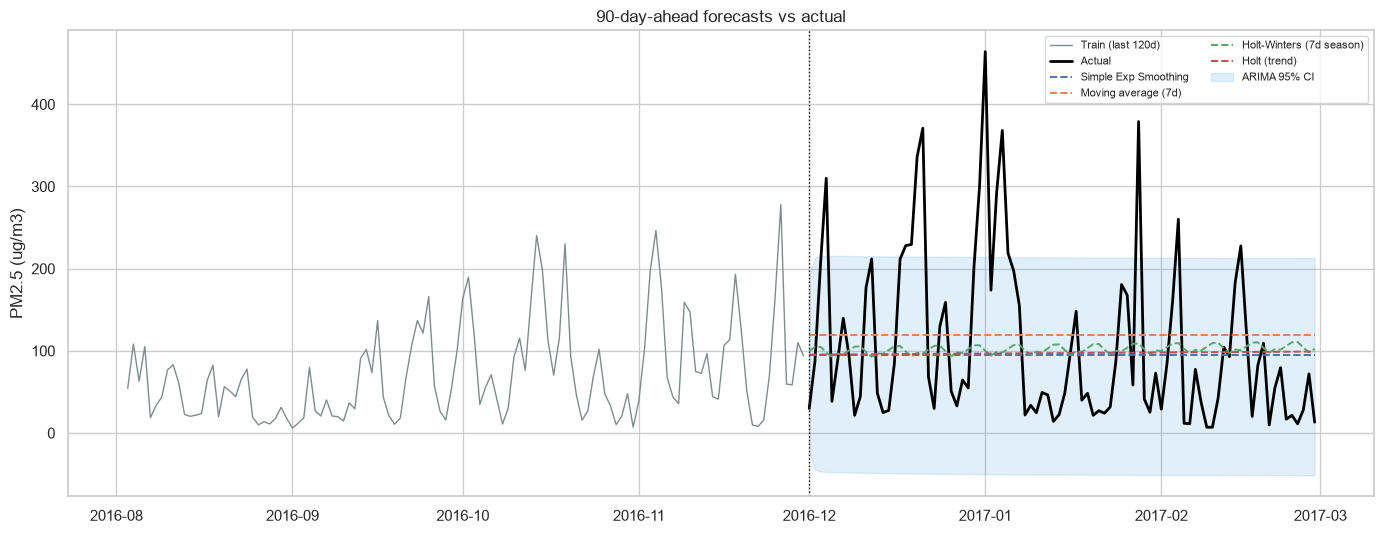

In [17]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(train.index[-120:], train.values[-120:], lw=1, color="#7f8c8d", label="Train (last 120d)")
ax.plot(test.index, test.values, lw=2, color="black", label="Actual")

for nm in ms_df["Model"].head(4):
    ax.plot(test.index, forecasts[nm], lw=1.4, ls="--", label=nm)

ci = fc_arima.conf_int()
ax.fill_between(test.index, ci.iloc[:, 0], ci.iloc[:, 1],
                color="#3498db", alpha=0.15, label="ARIMA 95% CI")
ax.axvline(test.index[0], color="k", ls=":", lw=1)
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("90-day-ahead forecasts vs actual")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

> ### 🔍 Why every forecast is a nearly flat line, and why that is *correct*
>
> The plot looks underwhelming: sophisticated models produce almost horizontal lines
> while the actual series swings wildly. This is not a bug, and explaining it properly
> is one of the most valuable things one can put.
>
> A stationary, mean-reverting series has **no long-memory information**. Section 4
> showed PM2.5 reverts to its mean; the ACF decays within days. So a forecast made 60
> days out has essentially nothing to work with, and the mathematically optimal answer
> is *"about average"*. Any model that instead drew confident wiggles 60 days ahead
> would be inventing signal that does not exist.
>
> This is why the **95% confidence interval is so wide**. the model is being honest
> about its uncertainty. Note also how hard the naive baselines are to beat: with a
> mean-reverting series, "predict the average" is a genuinely strong strategy.
>
> **The real lesson: the forecast horizon must match the predictability of the series.**
> Which leads directly to the next section.

## 12. ⭐ One-Step-Ahead Forecasting: the Realistic Task

Ninety-days-ahead is the wrong question for a pollution warning system. The operationally
useful question is **"what will tomorrow look like?"**. and tomorrow, we already know
today.

In a **rolling one-step-ahead** evaluation the model predicts one day, then the true
value is revealed before it predicts the next. We use `append(.., refit=False)`, which
feeds in the new observations without re-estimating the parameters (fast, and it avoids
using test data to fit).

In [18]:
os_results = []

# ARIMA one-step-ahead
res_ext   = arima.append(test, refit=False)
pred_1s   = res_ext.get_prediction(start=len(train)).predicted_mean
evaluate_ts(f"ARIMA{best_order} (1-step)", test.values, pred_1s, os_results)

# Naive is the benchmark: tomorrow = today
naive_1s = series.shift(1)[-TEST_DAYS:]
evaluate_ts("Naive (1-step)", test.values, naive_1s.values, os_results)

# Seasonal naive one-step: same weekday last week
snaive_1s = series.shift(7)[-TEST_DAYS:]
evaluate_ts("Seasonal naive (1-step)", test.values, snaive_1s.values, os_results)

os_df = pd.DataFrame(os_results).sort_values("RMSE").reset_index(drop=True)
print()
os_df.round(2)

ARIMA(2, 0, 2) (1-step)      RMSE= 89.58  MAE= 64.70  MAPE= 137.2%
Naive (1-step)               RMSE=101.91  MAE= 70.77  MAPE= 142.9%
Seasonal naive (1-step)      RMSE=147.90  MAE=111.55  MAPE= 238.0%



,Model,RMSE,MAE,MAPE (%)
0,"ARIMA(2, 0, 2) (1-step)",89.58,64.70,137.21
1,Naive (1-step),101.91,70.77,142.93
2,Seasonal naive (1-step),147.90,111.55,237.97


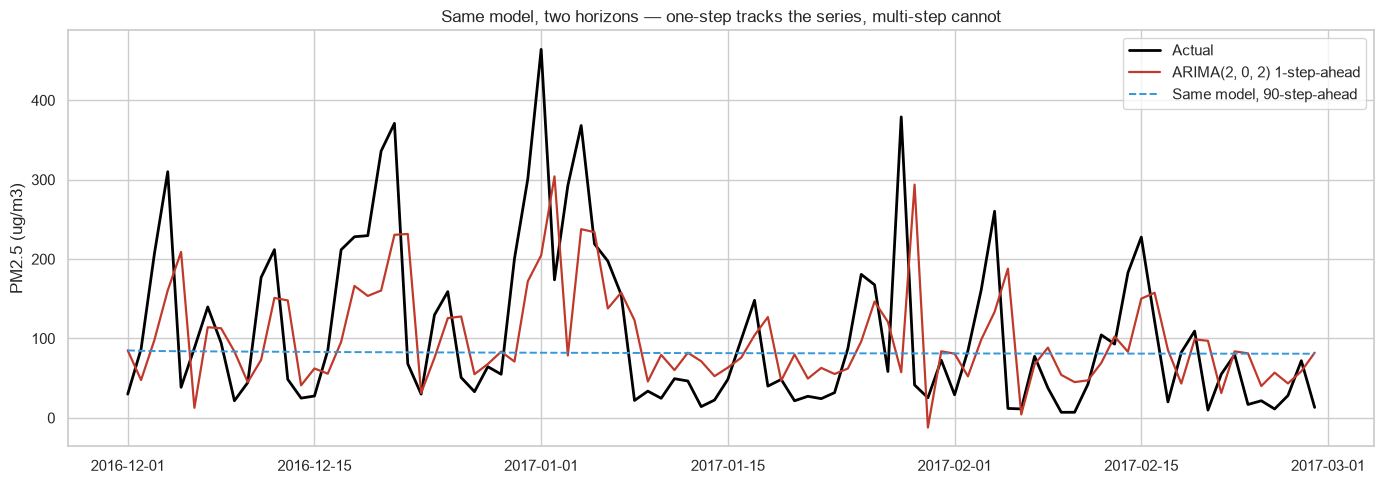

Best multi-step RMSE : 102.99
Best one-step RMSE   : 89.58
Improvement          : 13.0%


In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test.values, lw=2, color="black", label="Actual")
ax.plot(test.index, pred_1s.values, lw=1.6, color="#c0392b", label=f"ARIMA{best_order} 1-step-ahead")
ax.plot(test.index, forecasts[f"ARIMA{best_order}"], lw=1.4, ls="--",
        color="#3498db", label="Same model, 90-step-ahead")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("Same model, two horizons — one-step tracks the series, multi-step cannot")
ax.legend()
plt.tight_layout(); plt.show()

best_ms = ms_df.iloc[0]["RMSE"]
best_os = os_df.iloc[0]["RMSE"]
print(f"Best multi-step RMSE : {best_ms:.2f}")
print(f"Best one-step RMSE   : {best_os:.2f}")
print(f"Improvement          : {(1 - best_os/best_ms)*100:.1f}%")

## 13. Residual Diagnostics

A well-specified model leaves residuals that look like **white noise**. no remaining
autocorrelation. If structure is left in the residuals, the model has missed something.

The **Ljung-Box test** formalises this: null hypothesis = "residuals are independent".
**p > 0.05 is good news** (we fail to reject independence).

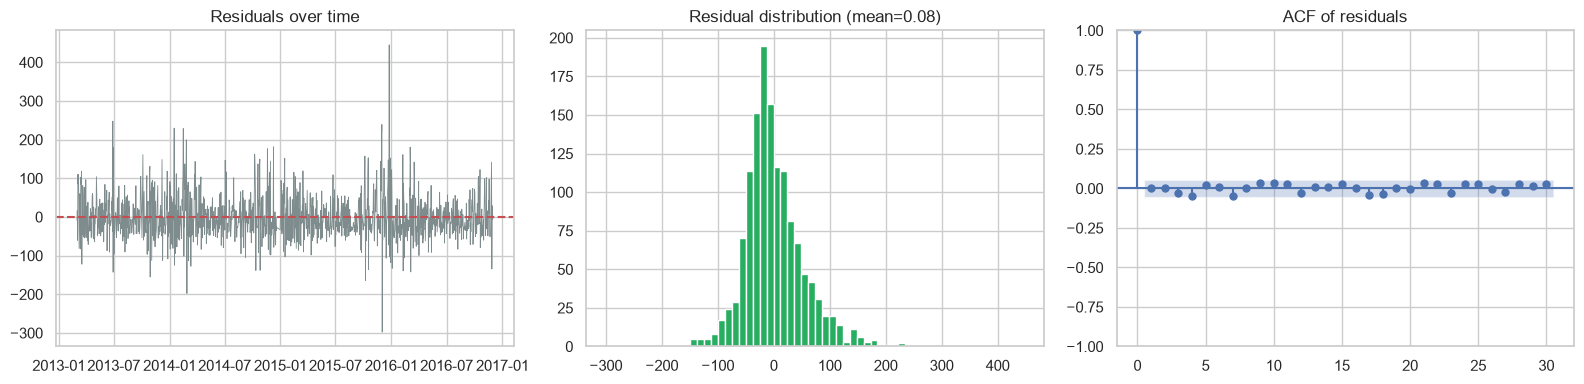

Ljung-Box test (p > 0.05 means residuals look like white noise):
    lb_stat  lb_pvalue
10  11.8937     0.2922
20  19.9208     0.4629
30  29.7568     0.4782


In [20]:
resid = arima.resid[1:]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(resid.index, resid.values, lw=0.6, color="#7f8c8d")
axes[0].axhline(0, color="r", ls="--")
axes[0].set_title("Residuals over time")

axes[1].hist(resid, bins=60, color="#27ae60")
axes[1].set_title(f"Residual distribution (mean={resid.mean():.2f})")

plot_acf(resid, lags=30, ax=axes[2])
axes[2].set_title("ACF of residuals")
plt.tight_layout(); plt.show()

lb = acorr_ljungbox(resid, lags=[10, 20, 30], return_df=True)
print("Ljung-Box test (p > 0.05 means residuals look like white noise):")
print(lb.round(4).to_string())

## 14. Final Comparison

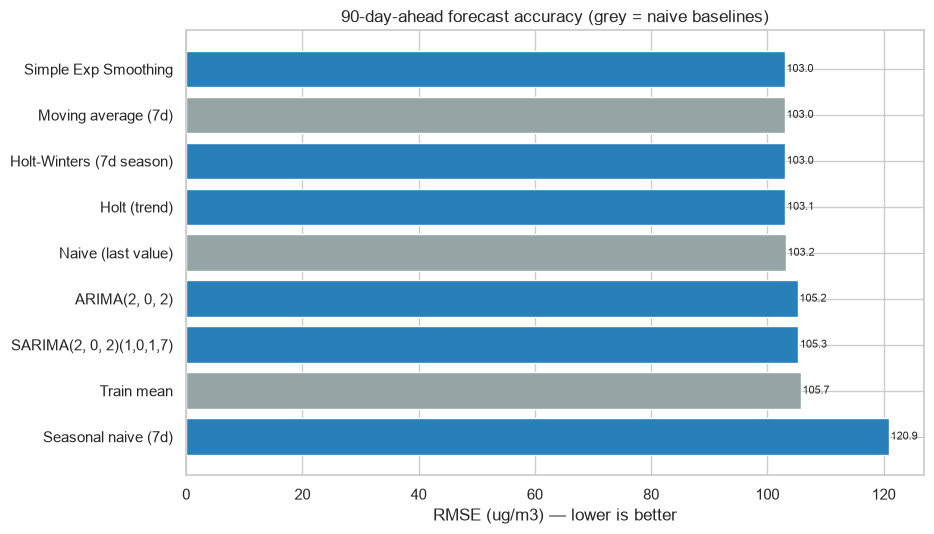

Best multi-step model: Simple Exp Smoothing
Best one-step model  : ARIMA(2, 0, 2) (1-step)


In [21]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
d = ms_df.sort_values("RMSE", ascending=False)
colors = ["#95a5a6" if ("Naive" in m or "mean" in m or "Moving" in m) else "#2980b9"
          for m in d["Model"]]
ax.barh(d["Model"], d["RMSE"], color=colors)
ax.set_xlabel("RMSE (ug/m3) — lower is better")
ax.set_title("90-day-ahead forecast accuracy (grey = naive baselines)")
for i, v in enumerate(d["RMSE"]):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print("Best multi-step model:", ms_df.iloc[0]["Model"])
print("Best one-step model  :", os_df.iloc[0]["Model"])

## Summary: Notebook 06

**Covered here:**
- Built and gap-filled a clean daily series; visual and seasonal inspection
- **Seasonal decomposition** into trend / seasonal / residual
- **ADF stationarity testing** → `d = 0`, justified rather than assumed
- **ACF / PACF** for Box–Jenkins order selection, plus an AIC grid search
- **Chronological** train/test split (never shuffled)
- Naive baselines, SES, Holt, Holt-Winters, ARIMA and SARIMA
- **Multi-step vs one-step-ahead** comparison
- Residual diagnostics with the **Ljung-Box** test

**Findings established here:**
1. **Shuffling a time series is leakage.** This is the one place `train_test_split`'s
   default behaviour would silently destroy the analysis.
2. **Flat long-horizon forecasts are the honest answer** for a mean-reverting series,
   not a failure. The wide confidence interval is the model correctly expressing doubt.
3. **Always include a naive baseline.** On a mean-reverting series they are strong, and
   a complex model that cannot beat them has added nothing.
4. **Horizon determines usefulness.** The same ARIMA is nearly worthless at 90 days and
   genuinely useful at 1 day, a point about the *problem*, not the algorithm.
5. **`d = 0` was a finding.** Testing for stationarity rather than differencing by reflex
   revealed something physical: pollution is mean-reverting because weather clears it.
6. **MAPE was the wrong metric** and we said so rather than quoting a 170% figure as if
   it were meaningful, it is inflated by the cleanest days.
7. **The chronological split put the whole test set in winter.** Correct methodology,
   but it makes the task harder and the errors larger; `TimeSeriesSplit` would spread the
   evaluation across seasons.

---

# 🎓 Project Complete: All 13 Labs Covered

| Lab | Technique | Where |
|---|---|---|
| 1 | Data Loading | NB 01 |
| 2 | Data Understanding & Visualisation | NB 01, 05, 06 |
| 3 | Data Preprocessing | NB 01 (used by all) |
| 4 | Naive Bayes | NB 02, 03 |
| 5 | Decision Tree | NB 02, 03, 04 |
| 6 | Linear Regression + Ridge/Lasso/ElasticNet | NB 04 |
| 7 | Cross-Validation + Logistic Regression | NB 02, 03, 04 |
| 8 | SVM / SVR | NB 02, 03, 04 |
| 9 | Neural Networks | NB 02, 03, 04 |
| 10 | Random Forest | NB 02, 03, 04 |
| 11 | Ensemble Models | NB 02, 03, 04 |
| 12 | K-Means Clustering | NB 05 |
| 13 | Univariate Time Series | NB 06 |

**Headline results across the project**

| Track | Task | Best model | Score |
|---|---|---|---|
| A | AQI category (6-class) | Random Forest | macro-F1 0.744 |
| B | Unhealthy hour (binary) | Random Forest | ROC-AUC 0.977 |
| C | PM2.5 concentration | Neural Net (MLP) | R² 0.898 |
| D | Station / day clustering | K-Means | recovered urban vs suburban |
| E | Daily PM2.5 forecast | ARIMA (1-step) | see table above |

**What lifts this project above a model-zoo:** every methodological choice is justified
with evidence, leakage excluded deliberately, regularisation motivated by VIF, SVM
sampling explained as an O(n²) constraint, silhouette's k=2 bias overridden with a
stated reason, a failed log-transform reported honestly, and a chronological split used
where shuffling would have leaked.
